In [4]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from skimage import measure, morphology
from scipy import ndimage
from skimage.draw import ellipsoid
from skimage.measure import EllipseModel
import matplotlib.patches as patches


def load_spect_data(filepath):
    """
    读取SPECT数据（NIfTI格式）
    """
    image = sitk.ReadImage(filepath)
    data = sitk.GetArrayFromImage(image)
    voxel_size = image.GetSpacing()
    return data, voxel_size



In [42]:
###  shujvyuan : Z:\Develop\Algorithm\数据集\cardiac_SPECT_data  000652515

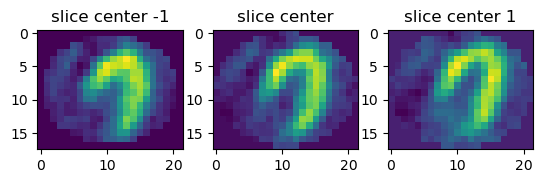

In [5]:
filepath = "./ogn.nii.gz"
# main(filepath)
img, voxelsize = load_spect_data(filepath)

ax = plt.subplot(131)
plt.imshow(img[5])
ax.set_title("slice center -1")
ax = plt.subplot(132)
plt.imshow(img[6])
ax.set_title("slice center")
ax = plt.subplot(133)
plt.imshow(img[7])
ax.set_title("slice center 1")
plt.show()


椭圆参数: 10.94316695855775 9.692501999215574 6.796864101455798 4.245548569158562 2.2393138350000443


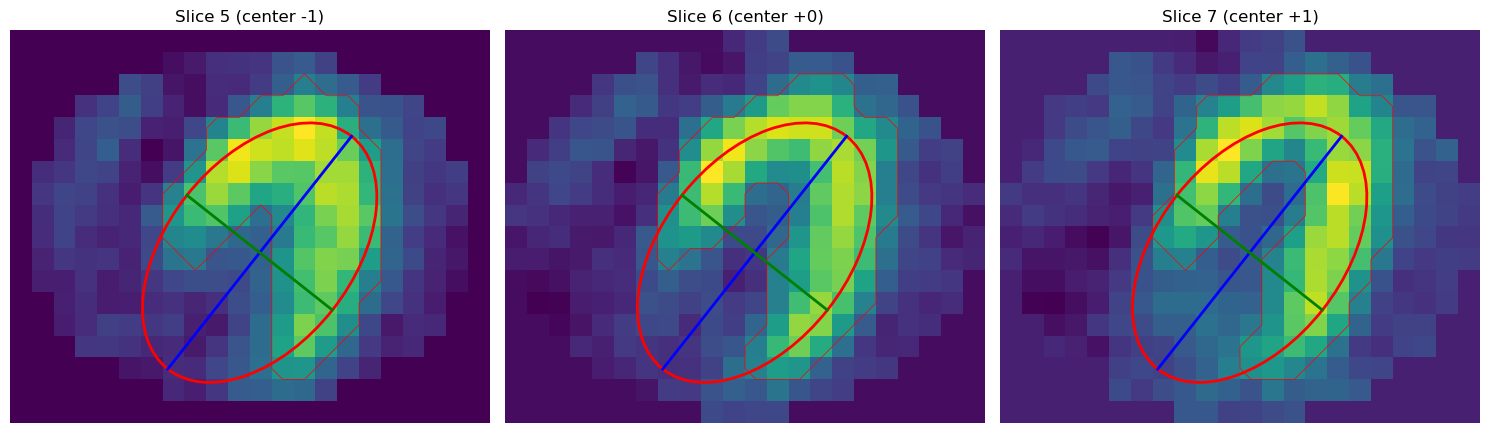

In [9]:
# 获取中心层mask和椭圆参数
mask = img[6]>300

# 获取轮廓点
contours = measure.find_contours(mask, 0.5)
contour = contours[0]  # 取最大轮廓

# 拟合椭圆
x = contour[:, 1]
y = contour[:, 0]
ellipse = EllipseModel()
if not ellipse.estimate(np.column_stack([x, y])):
    print("Failed to fit ellipse")

# 获取椭圆参数
xc, yc, a, b, theta = ellipse.params

# 调整参数
theta += 0.5
xc -= 1.5
yc += 1.5
a += 0.8
b -= .5

print("椭圆参数:", xc, yc, a, b, theta)

# 绘制三层切片
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, slice_idx in enumerate([5, 6, 7]):
    ax = axes[i]
    
    # 绘制原始图像
    ax.imshow(img[slice_idx])
    
    # 绘制mask轮廓
    mask_slice = img[slice_idx] > 300
    ax.contour(mask_slice, colors='red', linewidths=0.5)
    
    # 创建椭圆patch
    ellipse_patch = patches.Ellipse((xc, yc), 2*a, 2*b, 
                                  angle=np.degrees(theta),
                                  fill=False, color='red', linewidth=2)
    ax.add_patch(ellipse_patch)
    
    ax.axis('off')
    ax.set_title(f'Slice {slice_idx} (center {slice_idx-6:+d})')
    
    # 绘制长轴
    t = theta  # 椭圆的旋转角度
    dx = a * np.cos(t)  # 长轴x方向分量
    dy = a * np.sin(t)  # 长轴y方向分量
    ax.plot([xc - dx, xc + dx], [yc - dy, yc + dy], 'b-', linewidth=2, label='长轴')
    
    # 绘制短轴
    dx = b * np.cos(t + np.pi/2)  # 短轴x方向分量
    dy = b * np.sin(t + np.pi/2)  # 短轴y方向分量
    ax.plot([xc - dx, xc + dx], [yc - dy, yc + dy], 'g-', linewidth=2, label='短轴')
        
        

plt.tight_layout()
plt.show()

In [19]:
img.shape

(17, 18, 22)

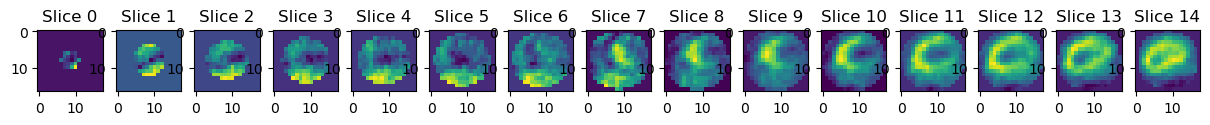

In [24]:
# 获取中心层mask和椭圆参数

plt.figure(figsize=(15, 1))
for i in range(15):
    # mask = img[i, 6] > 300
    # contours = measure.find_contours(mask, 0.5)
    # contour = contours[0]  # 取最大轮廓
    # x = contour[:, 1]
    # y = contour[:, 0]
    # ellipse = EllipseModel()
    plt.subplot(1, 15, i+1)
    plt.imshow(img[:, :, i])
    plt.title(f'Slice {i}')


椭圆参数: 9.752952504674148 6.6549346594726755 6 4 2.5555877144834023


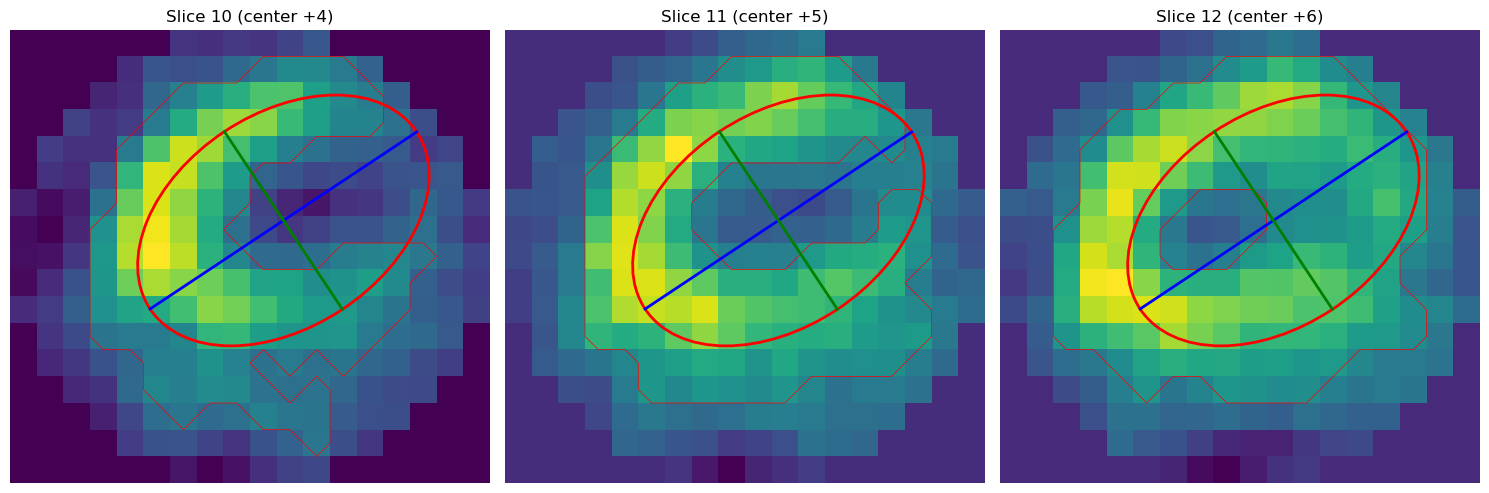

In [41]:
# 获取中心层mask和椭圆参数
mask = img[:,:, 11]>300

# 获取轮廓点
contours = measure.find_contours(mask, 0.5)
contour = contours[0]  # 取最大轮廓

# 拟合椭圆
x = contour[:, 1]
y = contour[:, 0]
ellipse = EllipseModel()
if not ellipse.estimate(np.column_stack([x, y])):
    print("Failed to fit ellipse")

# 获取椭圆参数
xc, yc, a, b, theta = ellipse.params

# 调整参数
# theta += 0.5
# xc -= 1.5
# yc += 1.5
# a += 0.8
# b -= .5

a = 6
b = 4
theta += 0.3

xc += 0.8
yc -= .8

print("椭圆参数:", xc, yc, a, b, theta)

# 绘制三层切片
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, slice_idx in enumerate([10, 11, 12]):
    ax = axes[i]
    
    # 绘制原始图像
    ax.imshow(img[:, :, slice_idx])
    
    # 绘制mask轮廓
    mask_slice = img[:, :, slice_idx] > 300
    ax.contour(mask_slice, colors='red', linewidths=0.5)
    
    # 创建椭圆patch
    ellipse_patch = patches.Ellipse((xc, yc), 2*a, 2*b, 
                                  angle=np.degrees(theta),
                                  fill=False, color='red', linewidth=2)
    ax.add_patch(ellipse_patch)
    
    ax.axis('off')
    ax.set_title(f'Slice {slice_idx} (center {slice_idx-6:+d})')
    
    # 绘制长轴
    t = theta  # 椭圆的旋转角度
    dx = a * np.cos(t)  # 长轴x方向分量
    dy = a * np.sin(t)  # 长轴y方向分量
    ax.plot([xc - dx, xc + dx], [yc - dy, yc + dy], 'b-', linewidth=2, label='长轴')
    
    # 绘制短轴
    dx = b * np.cos(t + np.pi/2)  # 短轴x方向分量
    dy = b * np.sin(t + np.pi/2)  # 短轴y方向分量
    ax.plot([xc - dx, xc + dx], [yc - dy, yc + dy], 'g-', linewidth=2, label='短轴')
        
        

plt.tight_layout()
plt.show()

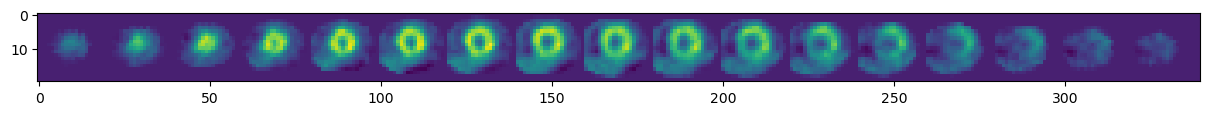

In [45]:
filepath = r"Y:\labspace\DataCollection\Project\RadiSmart\cardiac\healthy\000652515\161"


sitk_img = sitk.ReadImage(filepath)
img = sitk.GetArrayFromImage(sitk_img)

img.shape

plt.figure(figsize=(15, 1))
plt.imshow(img[0])
